# Employee Attrition Analysis

## Phase 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this phase is to explore the employee attrition dataset using statistical summaries and visualizations to identify patterns, trends, and factors influencing employee attrition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/clean/employee_attrition_clean.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Overview

The cleaned dataset is loaded for exploratory analysis.

In [3]:
attrition_counts = df["Attrition"].value_counts()

attrition_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

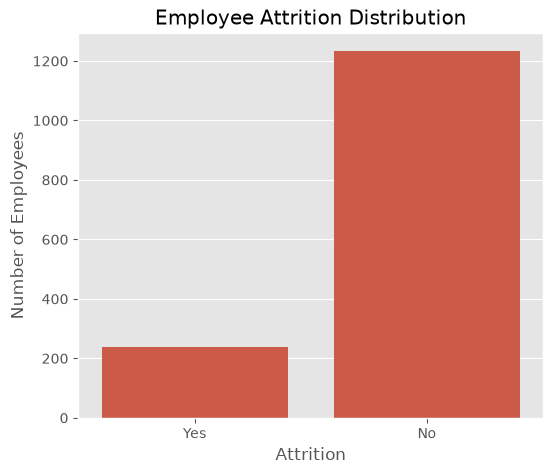

In [4]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")

plt.ylabel("Number of Employees")

plt.show()

In [5]:
attrition_percentage = df["Attrition"].value_counts(normalize=True)*100

attrition_percentage

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Insight 1

Most employees stayed with the company, while a smaller percentage left.

This indicates that employee attrition is relatively low, although understanding why employees leave remains important for improving employee retention.

In [6]:
attrition_percentage

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Department-wise Attrition Analysis

This analysis identifies which departments have the highest number of employees leaving the company.

In [7]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


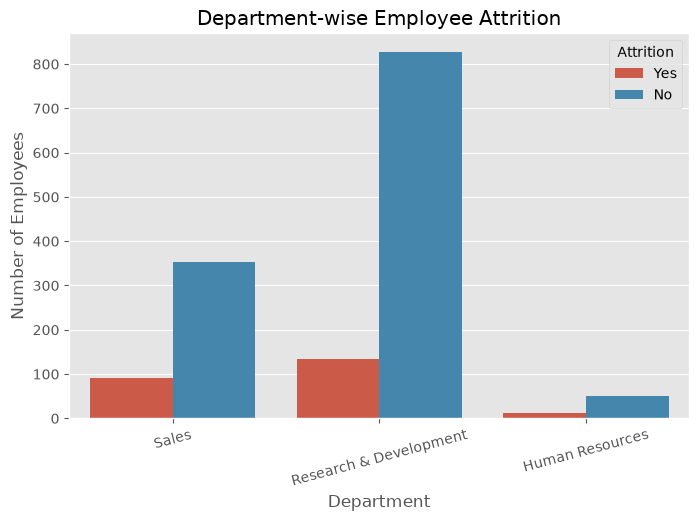

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)

plt.show()

## Insight 2

(We'll complete this after looking at the chart.)

## Insight 2

The Research & Development department has the largest number of employees. It also records the highest number of employees leaving the company.

The Sales department has the second-highest attrition count, while Human Resources has the lowest attrition due to having the smallest workforce.

Further analysis is required to determine whether the higher attrition in Research & Development is simply because it has more employees or because its attrition rate is actually higher.

## Overtime vs Employee Attrition

This analysis examines whether employees who work overtime are more likely to leave the company.

In [9]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


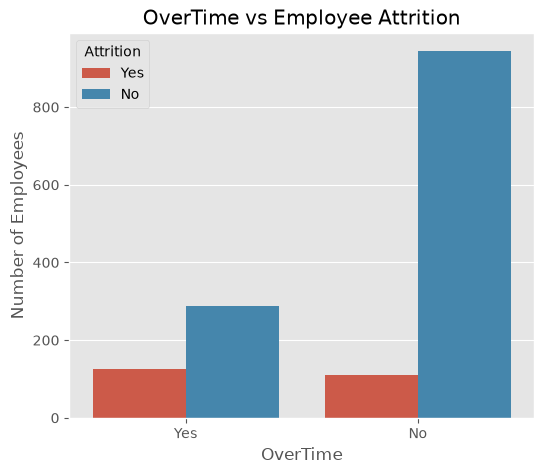

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("OverTime vs Employee Attrition")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.show()

## Insight 3

(We will write the insight after reviewing the chart.)

<Axes: xlabel='Department', ylabel='count'>

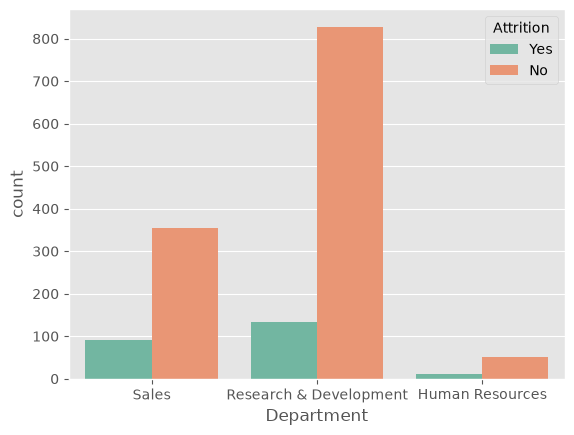

In [11]:
sns.countplot(
    data=df,
    x="Department",
    hue="Attrition",
    palette="Set2"
)

## Insight 3

Employees who work overtime appear to leave the company more frequently than employees who do not work overtime.

This suggests that overtime may be an important factor influencing employee attrition. High workloads and extended working hours could contribute to employee dissatisfaction and increase the likelihood of employees leaving the organization.

## Gender-wise Attrition Analysis

This analysis examines whether employee attrition differs between male and female employees.

In [13]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)

gender_attrition

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


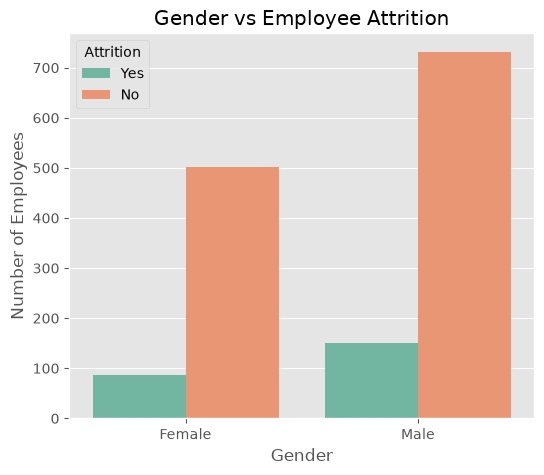

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition",
    palette="Set2"
)

plt.title("Gender vs Employee Attrition")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

<Axes: xlabel='Gender', ylabel='count'>

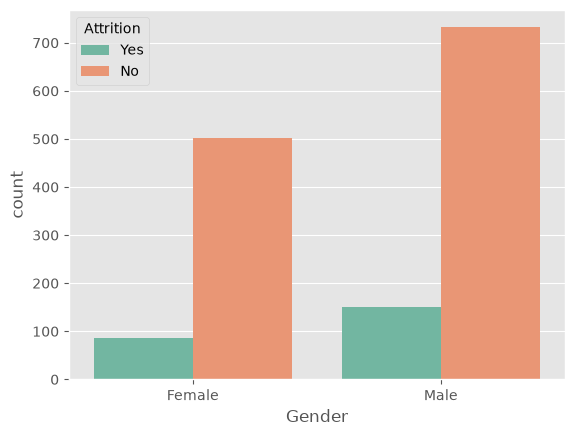

In [15]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition",
    palette="Set2"
)

## Insight 4

Male employees have a higher number of attrition cases compared to female employees.

However, the company also employs more male employees overall. Therefore, additional analysis using attrition percentages would be required to determine whether gender itself significantly influences employee attrition.

## Job Role-wise Attrition Analysis

This analysis identifies which job roles experience the highest employee attrition.

In [16]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


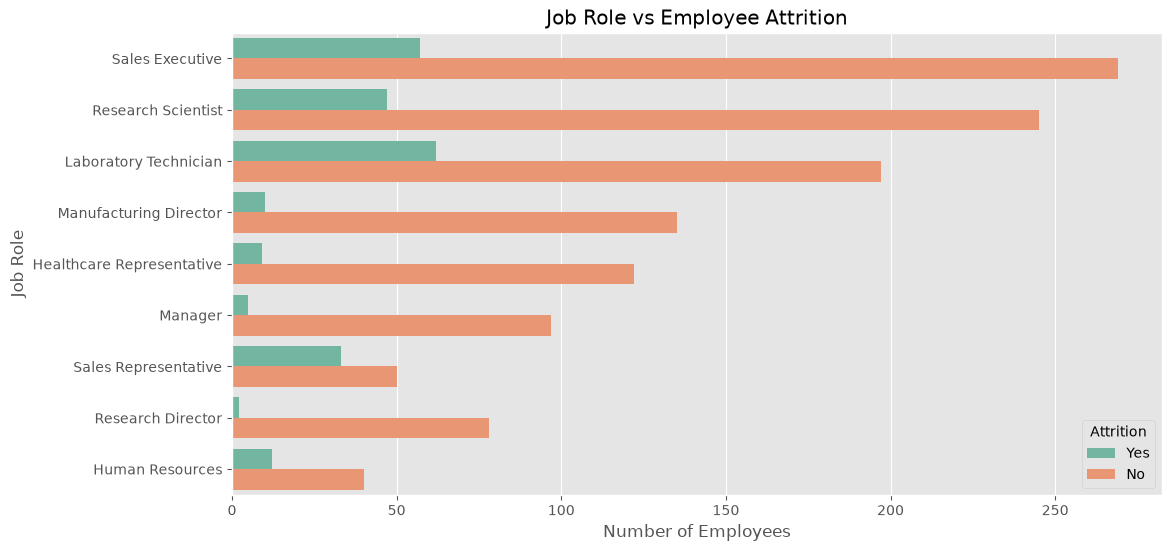

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    palette="Set2"
)

plt.title("Job Role vs Employee Attrition")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()

## Insight 5

Sales Executive, Research Scientist, and Laboratory Technician have the highest number of employees leaving the company.

Manager and Research Director show comparatively lower attrition counts.

However, these observations are based on employee counts. To determine which job role is most affected by attrition, attrition rates should also be calculated in future analysis.

## Monthly Income vs Employee Attrition

This analysis compares the salary distribution of employees who stayed with the company and those who left.

C:\Users\user\AppData\Local\Temp\ipykernel_7324\2224771989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


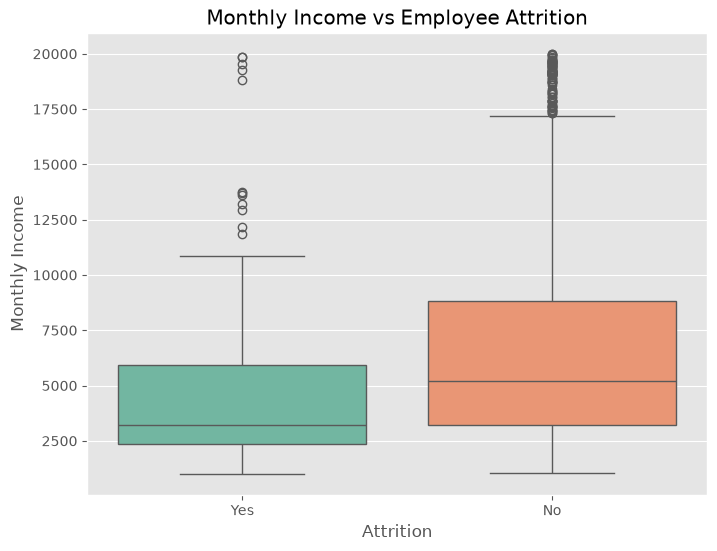

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

## Insight 6

Employees who left the company generally have lower monthly incomes compared to those who stayed.

The median monthly income is higher for employees who remained with the company. This suggests that lower salary levels may be associated with a greater likelihood of employee attrition.

Several high-income outliers are present in both groups, representing employees in senior or managerial positions.

## Age Distribution by Attrition

This analysis compares the age distribution of employees who stayed with the company and those who left.

C:\Users\user\AppData\Local\Temp\ipykernel_7324\3621435338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


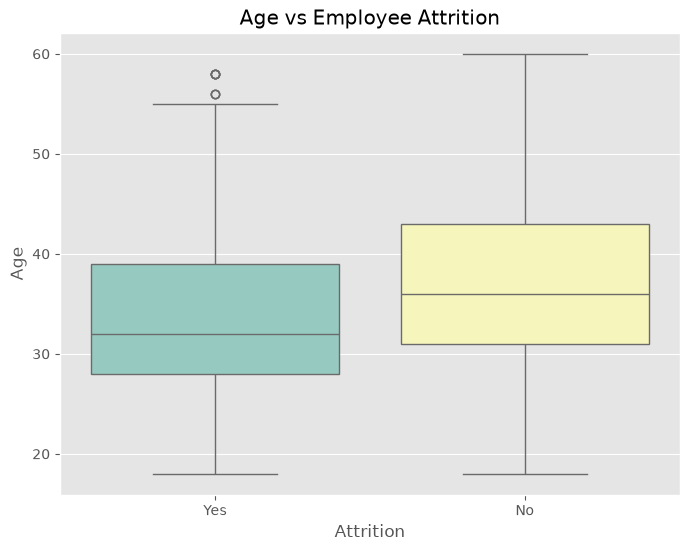

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age",
    palette="Set3"
)

plt.title("Age vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

## Insight 7

Employees who left the company tend to be younger than those who stayed.

The median age of employees who remained is higher, indicating that experienced employees are more likely to stay with the organization, while younger employees show relatively higher attrition.

No unrealistic age values were observed in the dataset.

# Key Findings

1. Overall attrition rate is approximately 16%.
2. Research & Development has the highest number of attrition cases.
3. Employees working overtime show higher attrition counts.
4. Sales Executive and Research Scientist are among the job roles with the highest attrition counts.
5. Salary and age distributions reveal additional patterns that should be considered by HR.

## Job Satisfaction vs Employee Attrition

This analysis examines whether employee job satisfaction is associated with employee attrition.

In [20]:
job_satisfaction = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"]
)

job_satisfaction

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


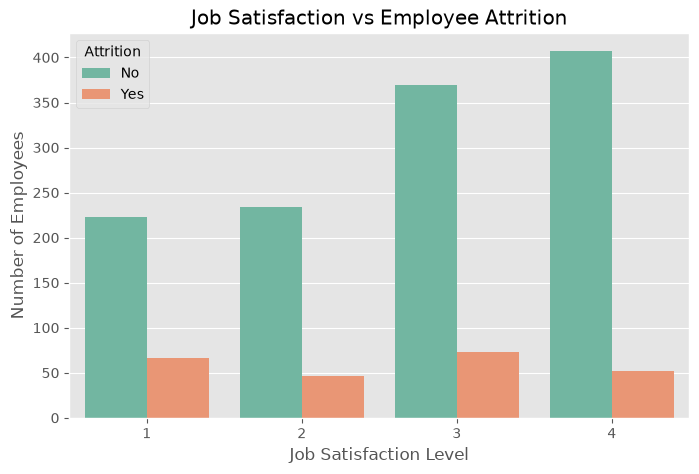

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition",
    palette="Set2"
)

plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()

## Insight 8

Employees with higher job satisfaction levels (Levels 3 and 4) have a larger number of employees who remained with the company.

Employees with lower job satisfaction levels (Levels 1 and 2) also show attrition cases. This suggests that job satisfaction may be associated with employee retention, although further analysis using attrition percentages would provide a more accurate comparison.

## Years at Company vs Employee Attrition

This analysis examines whether the number of years an employee has worked at the company is associated with employee attrition.

C:\Users\user\AppData\Local\Temp\ipykernel_7324\2908159512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


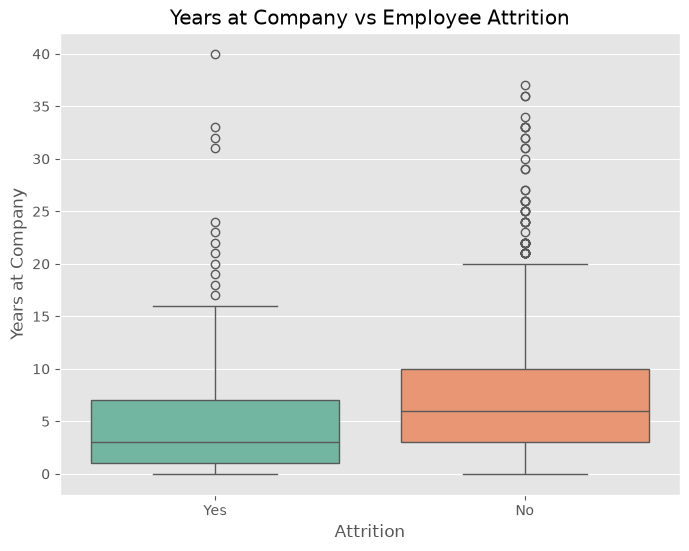

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany",
    palette="Set2"
)

plt.title("Years at Company vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

## Insight 9

Employees who left the company generally have fewer years of service compared to employees who stayed.

The median years at the company is higher for employees who remained with the organization, suggesting that employees who stay longer are more likely to continue their employment.

Although a few long-tenured employees also left the company, these are relatively uncommon observations.

## Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables in the dataset.

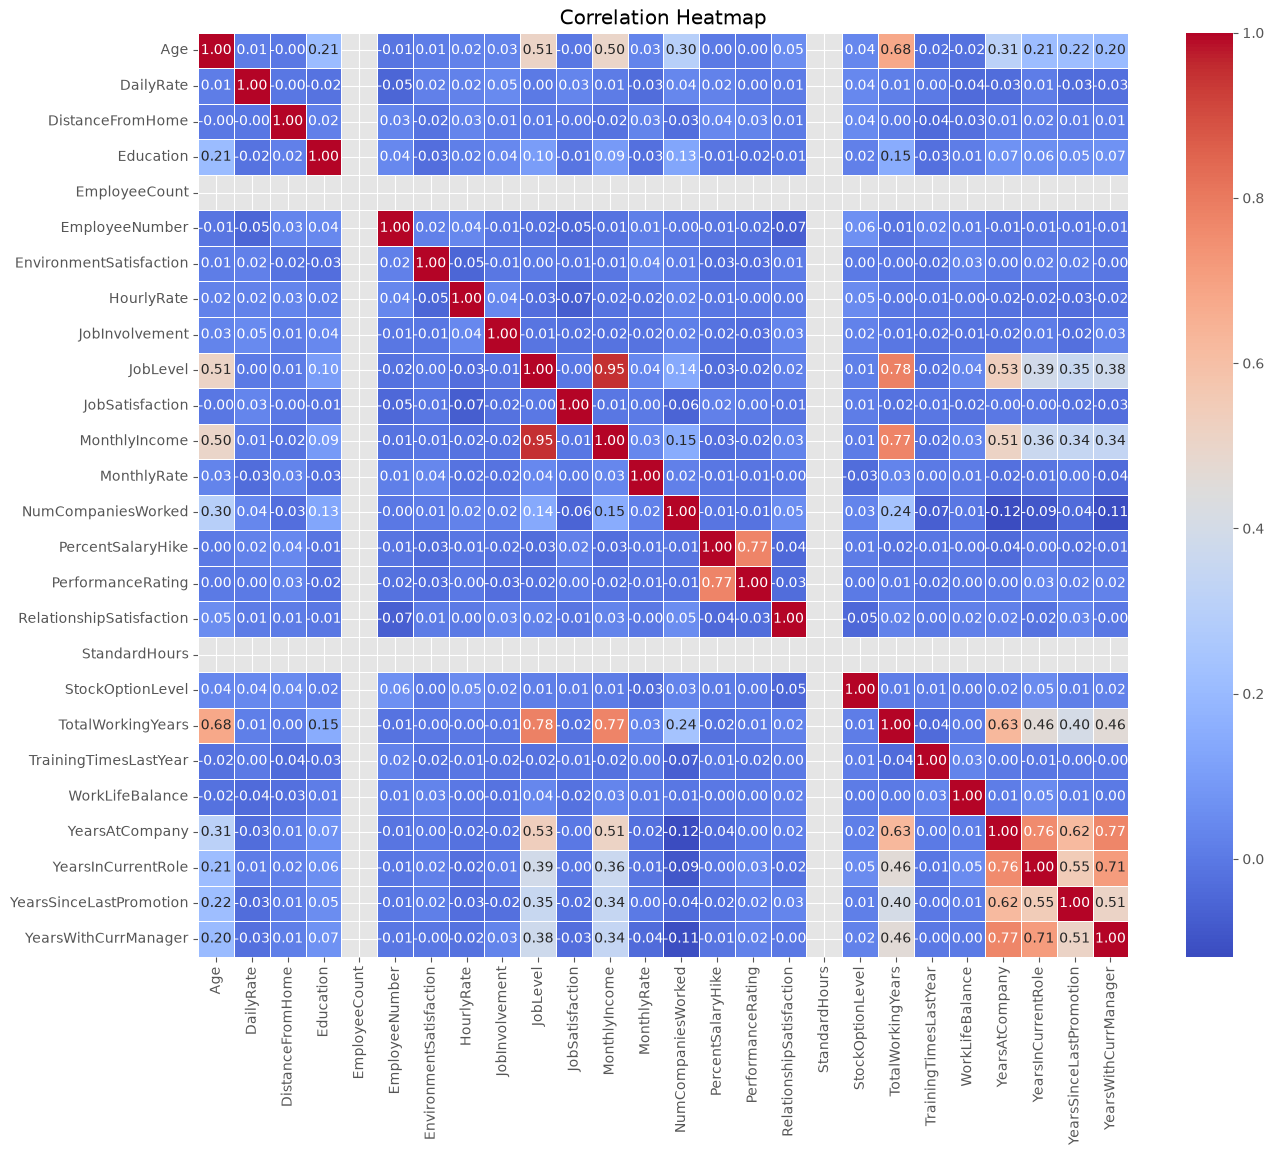

In [23]:
plt.figure(figsize=(15,12))

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Insight 10

The correlation heatmap provides an overview of the relationships between numerical variables.

Most variables exhibit weak to moderate correlations, indicating that employee attrition is influenced by multiple factors rather than a single numerical feature.

# Key Business Findings

1. The overall employee attrition rate is approximately 16%.
2. Research & Development has the highest number of attrition cases due to having the largest workforce.
3. Employees working overtime show higher attrition counts than employees who do not work overtime.
4. Sales Executive, Research Scientist, and Laboratory Technician show relatively high attrition counts.
5. Employees with lower monthly incomes appear more likely to leave the company.
6. Younger employees tend to leave the company more frequently than older employees.
7. Employees with fewer years at the company are more likely to leave.
8. Job satisfaction appears to be associated with employee retention.
9. Employee attrition is influenced by multiple factors rather than a single variable.

---

# Conclusion

The exploratory data analysis identified several factors associated with employee attrition, including overtime, salary, age, job role, years at the company, and job satisfaction. These findings provide valuable insights that can support HR decision-making and help develop strategies to improve employee retention.

## Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables in the dataset.

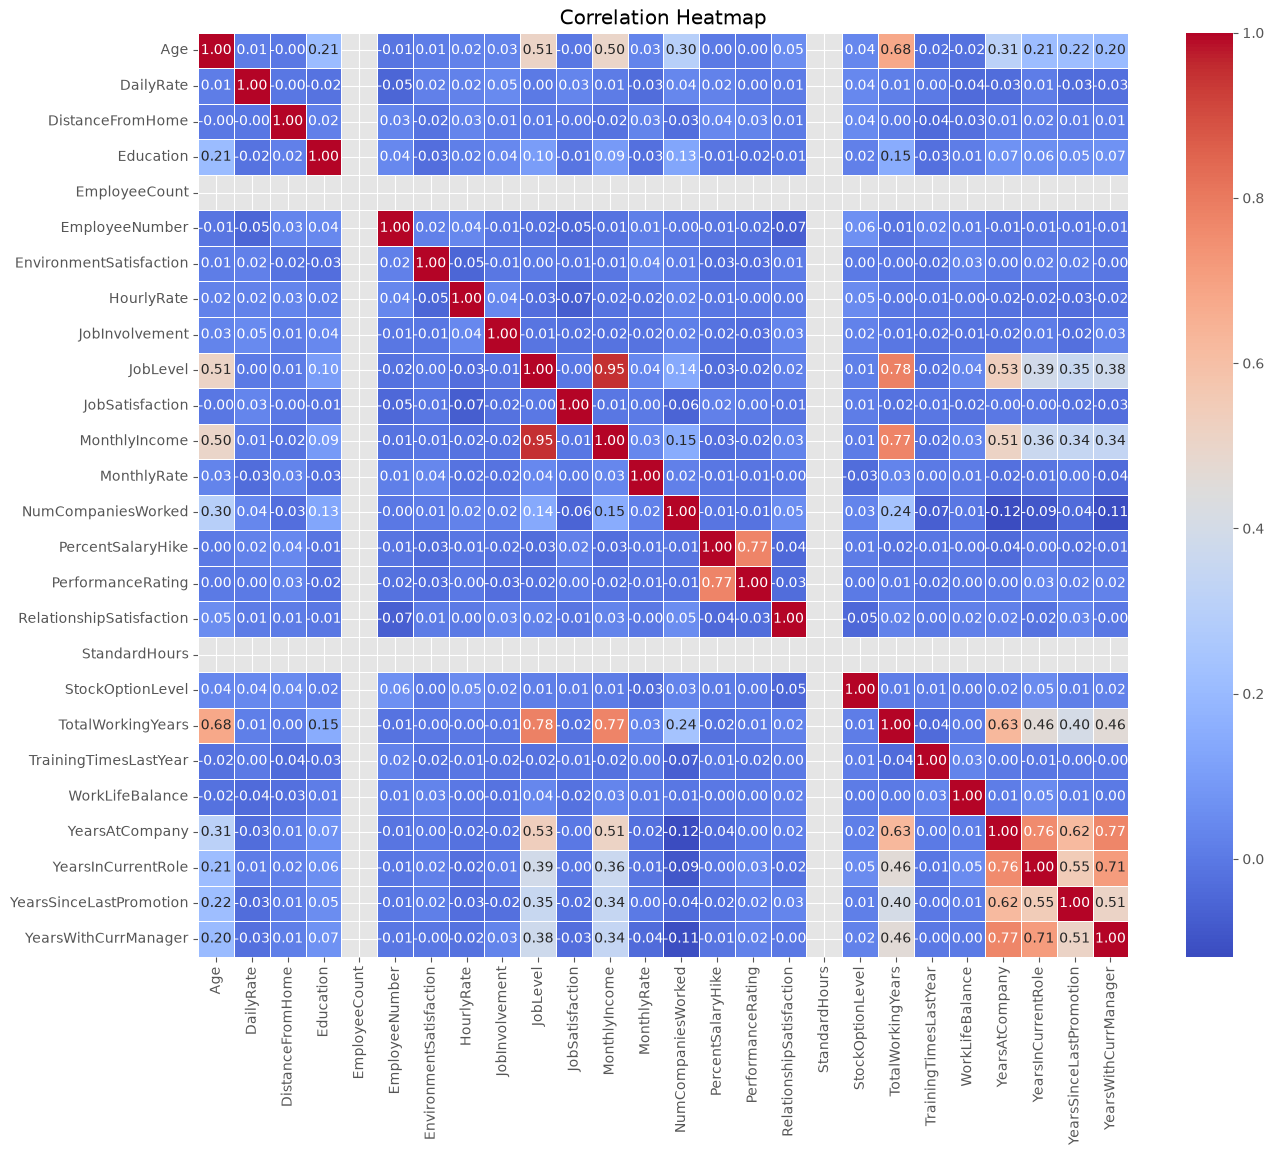

In [24]:
plt.figure(figsize=(15,12))

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Insight 10

The correlation heatmap provides an overview of the relationships between numerical variables.

Most numerical variables exhibit weak to moderate correlations, indicating that employee attrition is influenced by multiple factors rather than a single numerical variable.

# Key Business Findings

1. Approximately 16% of employees left the company.
2. Research & Development has the highest number of attrition cases due to having the largest workforce.
3. Employees working overtime show higher attrition counts.
4. Sales Executive, Research Scientist, and Laboratory Technician have relatively high attrition counts.
5. Employees with lower monthly incomes appear more likely to leave the company.
6. Younger employees tend to leave the company more frequently than older employees.
7. Employees with fewer years at the company are more likely to leave.
8. Job satisfaction appears to be associated with employee retention.
9. Employee attrition is influenced by multiple factors rather than a single variable.

# Conclusion

The exploratory data analysis identified several factors associated with employee attrition, including overtime, salary, age, job role, years at the company, and job satisfaction.

These findings can help HR teams understand employee behavior and develop strategies to improve employee retention.

The cleaned dataset and insights generated in this phase will be used for SQL analysis and Power BI dashboard development.